# Walkthrough (O como usar el codigo que ya alguien hizo)

Para beneficio de todos los demas los autores de [este paper](https://www.sciencedirect.com/science/article/abs/pii/S0010465524002790) publicaron el codigo para rcwa4D. En este documento usaremos su codigo que puede encontrar en [este repo](https://github.com/fancompute/rcwa4d).

---

## Librerias necesarias:
- rcwa4d: Este es el codigo de los investigadores, esta local, hasta donde yo se no lo han subido a pip. Igual es MIT entonces si alguien quiere que se sienta libre. Se que existe un paquete con rcwa pero es diferente. Esta libreria utiliza numpy y scipy por debajo para su implementacion.
- matplotlib: La usaremos unicamente para graficar resultados y las celdas con las que trabajaremos. No es necesario en si mismo si lo unico que te interesa es el resultado numerico.
- pickle: Para guardar objetos de python en discoduro como un archivo de modo que no tengamos que correr todo para acceder a los resultados cada vez
- tqdm: para poner barras de carga y no quedarnos mirando una pantalla en blanco sin saber que tanto avanzo

Los otros son componentes para las imagenes de matplotlib.

In [1]:
from rcwa4d import *
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm
%load_ext autoreload
%autoreload 2

/home/s1e7j/Devel/rcwa4d-pexp/rcwa4d/expansion4d.py:76: SyntaxWarning: invalid escape sequence '\i'
  N: G_max in x direction, G_x \in [-N,N]


## En donde vamos a trabajar

Ya que cargamos la libreria lo siguiente es montar la estructura con la que trabajaremos. Para nuestro caso usaremos dos capas con huecos circulares. Esta siguiente celda unicamente define la capa independiente. Aun no hemos puesto las rotaciones.

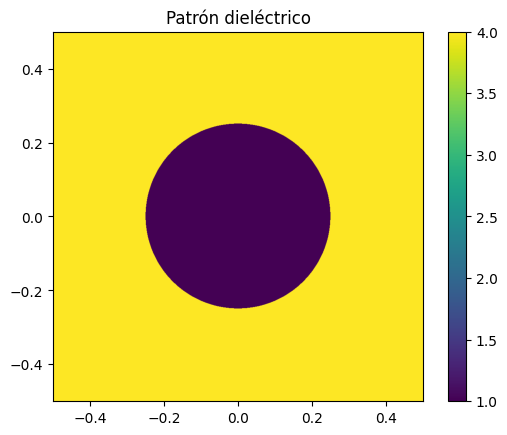

In [2]:
DEG = np.pi/180   # Correcto: conversión grados → radianes
Ny = Nx = 1000    ### resolución del patrón (cuadro 1000x1000)
eps = np.ones([Ny, Nx]) * 4   ### slab continuo sin huecos (permitividad = 4)
radius = 0.25     # Radio de los huecos (en unidades normalizadas por el periodo a)
thickness = 0.2   # Espesor de la capa (no se usa en este fragmento, pero se empleará después)
xs, ys = np.linspace(-0.5, 0.5, Nx), np.linspace(-0.5, 0.5, Ny)  # vectores de coordenadas
xs, ys = np.meshgrid(xs, ys)   # matrices de coordenadas (cada punto tiene su (x,y))
eps[xs**2 + ys**2 < radius**2] = 1   ### dentro de los círculos: permitividad del aire (ε=1)
plt.imshow(eps, extent=[-0.5,0.5,-0.5,0.5])
plt.colorbar()
plt.title('Patrón dieléctrico')
plt.show()

### Parámetros de truncamiento de la serie de Fourier:
ind = 1                           # orden máximo de difracción en cada dirección (±ind)
NM = (2*ind + 1)**2               # número total de órdenes de Fourier para una capa
NMNM = NM**2                      # probablemente para el tamaño de la matriz en sistemas bicapa

### Frecuencias a escanear (en unidades de c/a):
freqs = np.linspace(0.7, 0.84, 141)
twists = np.linspace(0, 45, 46) * DEG   # ángulos de torsión entre capas (en radianes)
kxs = np.linspace(0, 0.5, 51)           # componente x del vector de onda en unidades de 2π/a

## Primer calculo. Indices de reflexion y transmision para un caso concreto

El codigo trabaja en un objeto que mantiene toda la informacion necesaria en el estado. 

- **`epsr_list`**: lista de perfiles de permitividad dieléctrica para cada capa. Cada elemento puede ser una matriz 2D (en el espacio real) o directamente su transformada de Fourier. Internamente se convierte en la matriz de convolución de Fourier (Toeplitz) mediante `convmat2D` usando los órdenes `N` y `M`.
  
- **`thickness_list`**: lista con los espesores de cada capa (en las mismas unidades que `a`). Define la geometría vertical del sistema multicapa.

- **`orientation_list`**: lista de valores (1 o 2) que indican el sistema de coordenadas en que se define cada capa. Normalmente `1` = coordenadas sin torsión (referencia global), `2` = coordenadas torsionadas (rotadas un ángulo `twist`). Es clave para estructuras bicapa con rotación relativa.

- **`mu_list`** (opcional, por defecto `None`): lista de perfiles de permeabilidad magnética para cada capa. Si es `None`, se asume que todas las capas son no magnéticas y se establece la matriz identidad como convolución.

- **`twist`** (por defecto `0`): ángulo de torsión entre dos capas (normalmente entre la capa 0 y la 1). Se usa cuando `orientation_list` contiene valores `2` para aplicar la rotación correspondiente.

- **`gap_layer_indices`** (por defecto `[]`): lista de índices de capas que se consideran “gaps” (espacios vacíos o aire). Puede ser útil para reconstruir campos internos o para definir condiciones de contorno.

- **`N`** (por defecto `1`): orden máximo en la expansión de Fourier en la dirección `x`. Los vectores de onda recíprocos toman valores `G_x ∈ [-N, N]` (en pasos enteros). Determina el número total de órdenes de difracción en `x`: `(2N+1)`.

- **`M`** (por defecto `1`): orden máximo en la dirección `y`, análogo a `N`.

- **`a`** (por defecto `1.0`): unidad de longitud para normalizar frecuencias. Representa el periodo de la red (por ejemplo, en sistemas fotónicos suele ser el periodo del patrón). Las frecuencias se especifican en unidades de `c/a`.

- **`ax`** (opcional, por defecto `None`): constante de red en la dirección `x`. Si no se proporciona, se toma igual a `a`. Útil para redes rectangulares.

- **`ay`** (opcional, por defecto `None`): constante de red en la dirección `y`. Si no se proporciona, se toma igual a `a`.

- **`e_r`, `e_t`** (por defecto `1`): permitividades relativas para las regiones “r” y “t” (pueden referirse a medios isotrópicos o a componentes diagonales en algún formalismo de medios anisotrópicos). En muchas implementaciones se usan para definir el background o para capas homogéneas.

- **`m_r`, `m_t`** (por defecto `1`): permeabilidades relativas análogas a `e_r` y `e_t`.

- **`verbose`** (por defecto `1`): nivel de verbosidad para impresión de información durante la ejecución.

### Atributos internos que se inicializan
Además, el constructor asigna varios atributos que serán usados en los cálculos:
- `self.N`, `self.M`, `self.NM` (donde `NM = (2N+1)*(2M+1)`, el número total de órdenes de Fourier).
- `self.ER`: lista de matrices de convolución de la permitividad para cada capa.
- `self.UR`: lista de matrices de convolución de la permeabilidad (o identidad si no se especifica `mu_list`).
- `self.layer_thicknesses`, `self.orientations`, `self.twist`, `self.gap_layer_indices`, `self.a`, `self.ax`, `self.ay`, `self.e_r`, `self.e_t`, `self.m_r`, `self.m_t`, `self.verbose`.
- Variables auxiliares para reconstrucción de campos internos: `self.Sg`, `self.internal_Smats`, `self.internal_lambdas`, `self.internal_Ws`, `self.internal_Vs` (inicialmente `None` o listas vacías).

In [3]:
obj2 = rcwa([eps,eps], [thickness,thickness], [1,2],twist=1e-4, N=ind, M=ind, verbose=1)
"""
La linea anterior define el objeto con el solucionador.
- La primera variable define las capas. Es decir, ponemos dos capas que en este caso tienen la misma geometria.
- La segunda variable pone el grosor de la capa, para nuestro caso cada una de las capas tiene el mismo grosor.
- La tercera variable es cual es la capa base y si estara girada el angulo planteado posteriormente o no.
- La cuarta variable es el angulo que estamos rotando.
- Las siguientes son los ordenes maximos para truncar la transformada y la opcion de que mensione cada paso que ejecute.
"""
obj2.set_freq_k(freqs[0], (0, 0)) # Estamos poniendo la frecuencia angular normalizada. Para nuestro caso estamos simplemente poniendo la
# primera frecuencia que vamos a mirar. Esto nos dice que la frecuencia es 0.7 y (0, 0) implica que vamos a impactar de manera normal
(r,t), (reflected,transmitted) = obj2.get_RT(0,1, storing_intermediate_Smats=True) # Solucion del problema de reflexion y transmision total.
# r y t son la reflexion y transmision total dadas las condiciones planteadas previamente. la otra tupla corresponde con los vectores de
# cada caso en el orden 0

setting freq k...
solving Smat 4D...
expanding cinc
got R,T,R+T 0.022103168621005923 0.9778968313789932 0.9999999999999991


# Ahora vamos a encontrar un equivalente a estrcutura de bandas

Como en el caso de cristales lo que haremos esencialmente sera repetir el proceso anterior pero ahora para multiples frecuencias (las que definimos en la parte de arriba) de modo que para una misma configuración (en este caso de 1 grado) vamos a encontrar su transmision total para cada caso y asi tener un equivalente a las bandas. Esto es una aproximacion pues el metodo no es periodico como se explico previamente y por tanto no es igual si no equivalente.

In [ ]:
trans = []
twist = 1*DEG
for kx in tqdm(kxs):
    for freq in freqs:
        obj2 = rcwa([eps,eps], [thickness,thickness], [1,2],twist=twist, N=ind, M=ind, verbose=0)
        obj2.set_freq_k(freq, (kx, 0))
        (r,t), (reflected,transmitted) = obj2.get_RT(0,1)
        trans.append(t)
trans = np.array(trans).reshape(len(kxs),len(freqs))

# Como pueden ver es un proceso relativamente lento, por lo tanto lo mejor (y esto es solo buena practica) es guardar
# los resultados en alguna parte, para ello usaremos pickel

with open('transmission_data.pkl', 'wb') as f:
    pickle.dump(trans, f)

  8%|████████████                                                                                                                                              | 4/51 [01:03<12:30, 15.96s/it]

In [ ]:
# Cargamos desde pickel para tener resultados que mostrar
with open('transmission_data.pkl', 'rb') as f:
    trans = pickle.load(f)
plt.imshow(trans,extent=[freqs[0],freqs[-1],kxs[0], kxs[-1]],aspect='auto',origin='lower')
plt.xlabel('freq (c/a)')
plt.ylabel('kx (2π/a)')
plt.colorbar()
plt.show()

# Ahora haremos lo mismo pero cambiaremos en vez del vector de onda cambiaremos el angulo entre las capas

In [ ]:
trans = []
for twist in tqdm(twists):
    for freq in freqs:
        obj2 = rcwa([eps,eps], [thickness,thickness], [1,2],twist=twist, N=ind, M=ind, verbose=0)
        obj2.set_freq_k(freq, (0, 0))
        (r,t), (reflected,transmitted) = obj2.get_RT(0,1)
        trans.append(t)
trans = np.array(trans).reshape(len(twists),len(freqs))
with open('transmission_data_vary_twist.pkl', 'wb') as f:
    pickle.dump(trans, f)

In [ ]:
with open('transmission_data_vary_twist.pkl', 'rb') as f:
    trans = pickle.load(f)
plt.imshow(trans,extent=[freqs[0],freqs[-1],twists[0]/DEG, twists[-1]/DEG],aspect='auto',origin='lower')
plt.xlabel('freq (c/a)')
plt.ylabel('twist (deg)')
plt.colorbar()
plt.show()

In [ ]:
# Ahora graficamos la transmision total respecto a la frecuencia para 3 giros 0, 23 y 45 grados
for twisti in [0,23,45]:
    plt.plot(freqs,trans[twisti,:],label=f'twist={twists[twisti]/DEG:.1f}º')
plt.xlabel('freq (c/a)'); plt.ylabel('Total transmission'); plt.legend()
plt.show()